The pipeline ensures that:

All preprocessing happens automatically (no manual .fit_transform() calls).

When you later call .predict() or .score(), the same preprocessing is applied to new data.


fit a Polynomial Regression model on some non-linear data
and use a pipeline so all preprocessing happens automatically.

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Create a simple non-linear dataset
# -------------------------------
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = 3 * (X.squeeze() ** 2) + 2 * X.squeeze() + np.random.randn(50) * 5  # y = 3x² + 2x + noise
# -------------------------------
# 2️⃣ Build a Pipeline
# -------------------------------
model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2)),  # Step 1: Add x²
    ("scaler", StandardScaler()),                     # Step 2: Scale features
    ("regressor", LinearRegression())                 # Step 3: Fit Linear Model
])

# -------------------------------
# 3️⃣ Train the model
# -------------------------------
model.fit(X, y)

# -------------------------------
# 4️⃣ Make predictions
# -------------------------------
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred = model.predict(X_test)

# -------------------------------
# 5️⃣ Visualize
# -------------------------------
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Model prediction")
plt.title("Polynomial Regression with StandardScaler (Pipeline)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# Evaluate Performance

from sklearn.metrics import mean_squared_error, r2_score

y_train_pred = model.predict(X)
mse = mean_squared_error(y, y_train_pred)
r2 = r2_score(y, y_train_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {np.sqrt(mse):.3f}")
print(f"R² Score: {r2:.3f}")



### Complete ML comparison setup — using pipelines to compare:

1️⃣ Linear Regression

2️⃣ Polynomial Regression (Linear + PolynomialFeatures)

3️⃣ Support Vector Regression (SVR)

4️⃣ Random Forest Regressor

5️⃣ Gradient Boosting Regressor


Create non-linear data

Apply StandardScaler, PolynomialFeatures, etc. through Pipeline

Compare each model’s RMSE and R² score


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# 1️⃣ Create non-linear dataset
# -------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 80).reshape(-1, 1)
y = 3 * (X.squeeze() ** 2) + 2 * X.squeeze() + np.random.randn(80) * 8  # y = 3x² + 2x + noise

# -------------------------------
# 2️⃣ Define models with pipelines
# -------------------------------

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Polynomial Regression (deg=2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "SVR (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
}

# -------------------------------
# 3️⃣ Train & Evaluate
# -------------------------------
results = {}

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    results[name] = {"RMSE": rmse, "R2": r2}
    print(f"{name}: RMSE={rmse:.3f}, R²={r2:.3f}")

# -------------------------------
# 4️⃣ Visualization
# -------------------------------
X_test = np.linspace(0, 10, 200).reshape(-1, 1)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="gray", alpha=0.5, label="Actual Data")

for name, model in models.items():
    y_pred = model.predict(X_test)
    plt.plot(X_test, y_pred, label=name)

plt.title("Model Comparison (Regression Pipelines)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

A realistic ML experiment — 
with proper train–test split and test-set evaluation for fair model comparison.

We’ll use the same dataset, but now check how well each model generalizes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# ----------------------------------------
# 1️⃣ Create synthetic non-linear dataset
# ----------------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 3 * (X.squeeze() ** 2) + 2 * X.squeeze() + np.random.randn(100) * 10  # Non-linear + noise

# ----------------------------------------
# 2️⃣ Train-Test Split
# ----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------
# 3️⃣ Define Models with Pipelines
# ----------------------------------------
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Polynomial Regression (deg=2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "SVR (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
}

# ----------------------------------------
# 4️⃣ Train, Predict, Evaluate
# ----------------------------------------
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    results[name] = {
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "Train R²": r2_train,
        "Test R²": r2_test
    }

# ----------------------------------------
# 5️⃣ Display Results
# ----------------------------------------
import pandas as pd
results_df = pd.DataFrame(results).T
print(results_df.round(3))

# ----------------------------------------
# 6️⃣ Visualize Predictions
# ----------------------------------------
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color="gray", alpha=0.4, label="Train data")
plt.scatter(X_test, y_test, color="black", alpha=0.6, label="Test data")

for name, model in models.items():
    plt.plot(X_plot, model.predict(X_plot), label=name)

plt.title("Regression Model Comparison (Train/Test Split)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


Using Cross-Validation (CV) to measure how well each model generalizes across multiple splits of the data.

This approach helps:
    
Avoid lucky/unlucky test splits
    
Get a more stable and fair estimate of performance

Easily rank models by their mean performance (like RMSE)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error

# ----------------------------------------
# 1️⃣ Create Synthetic Non-linear Dataset
# ----------------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 120).reshape(-1, 1)
y = 3 * (X.squeeze() ** 2) + 2 * X.squeeze() + np.random.randn(120) * 10  # Non-linear pattern

# ----------------------------------------
# 2️⃣ Define Models with Pipelines
# ----------------------------------------
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Polynomial Regression (deg=2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "SVR (RBF Kernel)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
}

# ----------------------------------------
# 3️⃣ Define Cross-Validation Strategy
# ----------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------------------
# 4️⃣ Evaluate Each Model using RMSE
# ----------------------------------------
scorer = make_scorer(mean_squared_error, greater_is_better=False)  # We'll take sqrt later
results = {}

for name, model in models.items():
    # cross_val_score returns negative MSE (because sklearn assumes higher is better)
    neg_mse_scores = cross_val_score(model, X, y, scoring=scorer, cv=cv)
    rmse_scores = np.sqrt(-neg_mse_scores)
    
    results[name] = {
        "Mean RMSE": rmse_scores.mean(),
        "Std RMSE": rmse_scores.std()
    }

# ----------------------------------------
# 5️⃣ Show Results as a Sorted Table
# ----------------------------------------
results_df = pd.DataFrame(results).T.sort_values("Mean RMSE")
print("\nCross-Validation RMSE (lower is better):\n")
print(results_df.round(3))

# ----------------------------------------
# 6️⃣ Visualize Model Fits
# ----------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="gray", alpha=0.4, label="Actual Data")

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X_plot)
    plt.plot(X_plot, y_pred, label=name)

plt.title("Model Comparison using Cross-Validation")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


We’ll build a full experiment showing how increasing polynomial degree affects:

📉 RMSE (error)

📈 R² (goodness of fit)

🎨 and how the model curve changes

You’ll see the transition from underfitting → just right → overfitting.

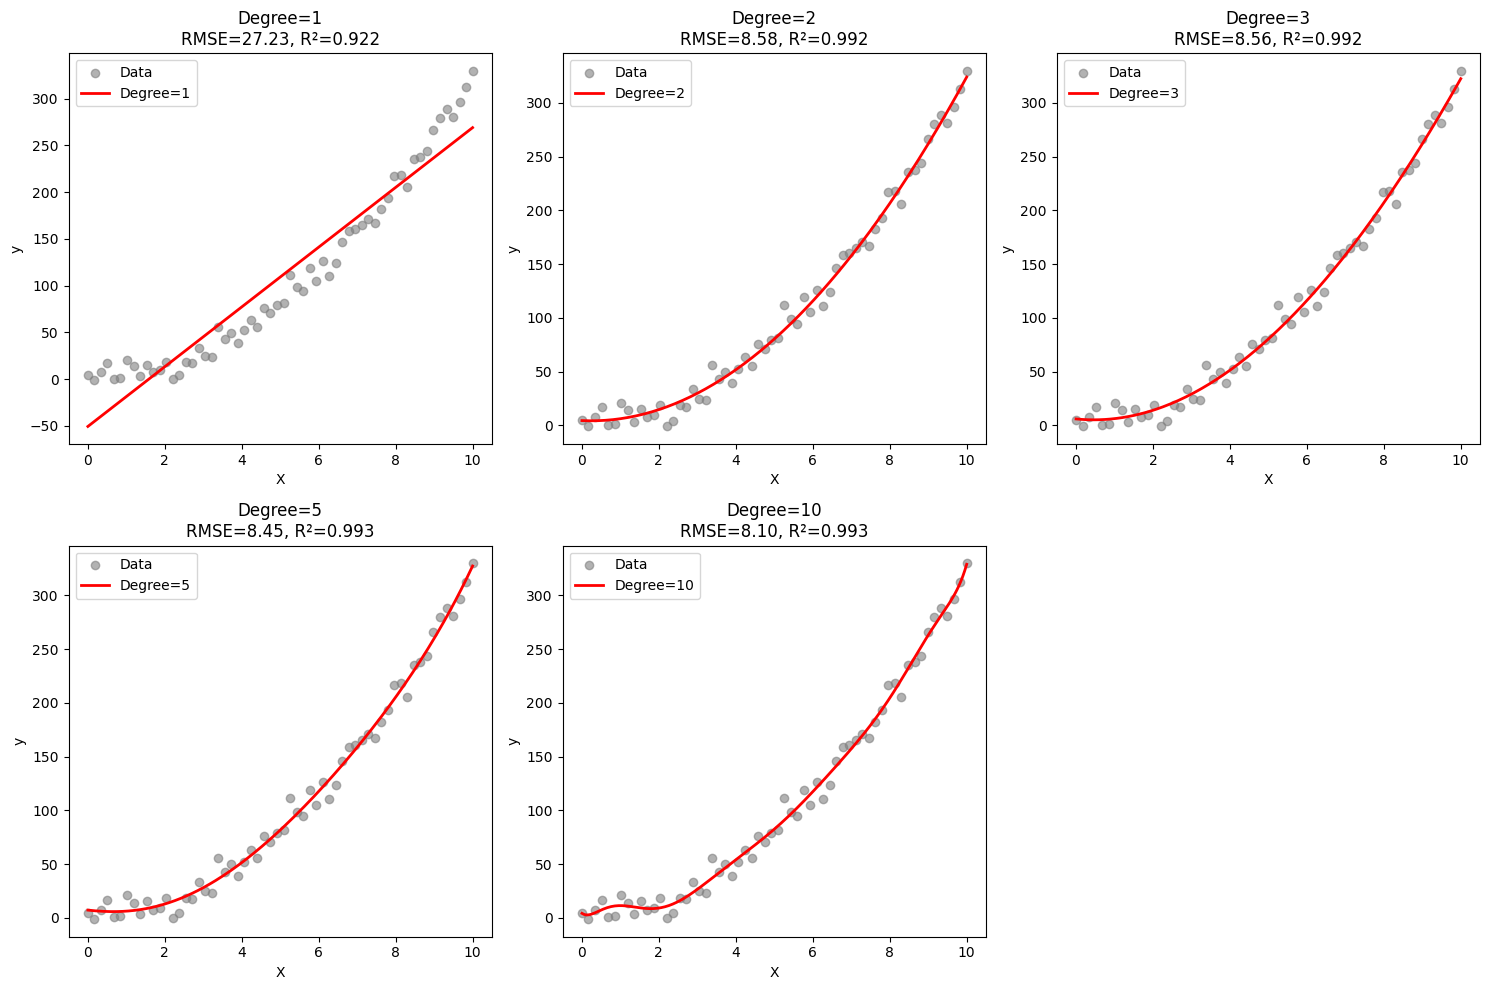

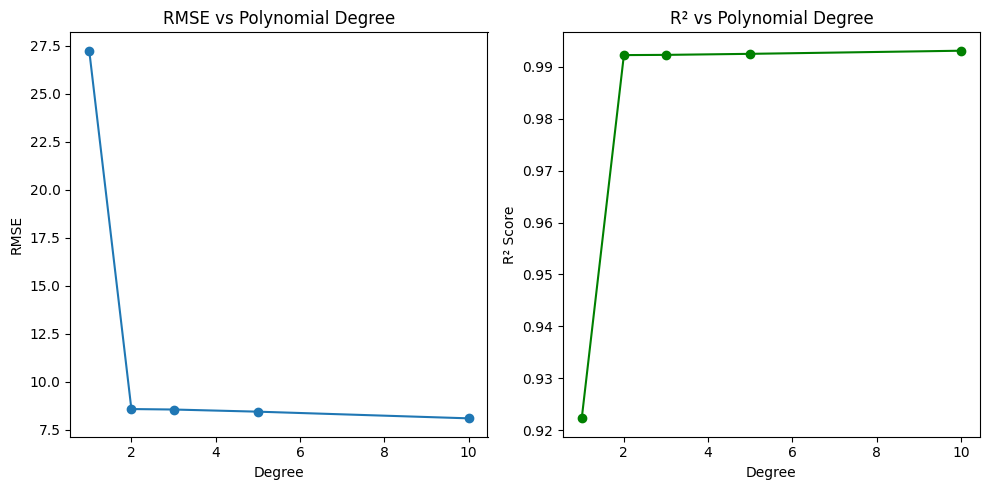

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# 1️⃣ Create non-linear dataset
# -------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 60).reshape(-1, 1)
y_true = 3 * (X.squeeze() ** 2) + 2 * X.squeeze()
y = y_true + np.random.randn(60) * 10  # add noise

# -------------------------------
# 2️⃣ Try different polynomial degrees
# -------------------------------
degrees = [1, 2, 3, 5, 10]
results = []

plt.figure(figsize=(15, 10))
for i, degree in enumerate(degrees, 1):
    # Build pipeline
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    
    # Train model
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Compute metrics
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2 = r2_score(y, y_pred)
    results.append((degree, rmse, r2))
    
    # Plot model curve
    X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    
    plt.subplot(2, 3, i)
    plt.scatter(X, y, color="gray", alpha=0.6, label="Data")
    plt.plot(X_plot, y_plot, color="red", linewidth=2, label=f"Degree={degree}")
    plt.title(f"Degree={degree}\nRMSE={rmse:.2f}, R²={r2:.3f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# 3️⃣ Plot RMSE and R² vs Degree
# -------------------------------
degrees, rmse_vals, r2_vals = zip(*results)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(degrees, rmse_vals, marker="o")
plt.title("RMSE vs Polynomial Degree")
plt.xlabel("Degree")
plt.ylabel("RMSE")

plt.subplot(1,2,2)
plt.plot(degrees, r2_vals, marker="o", color="green")
plt.title("R² vs Polynomial Degree")
plt.xlabel("Degree")
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()



Extending this same experiment with a train–test split,

so we can see overfitting visually — where train R² increases but test R² drops as degree rises?

In [18]:
# Creating train/test experiment showing overfitting with increasing polynomial degree.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------
# Create non-linear dataset
# -------------------------------
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y_true = 3 * (X.squeeze() ** 2) + 2 * X.squeeze()
y = y_true + np.random.randn(100) * 10  # add noise

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

degrees = [1, 2, 3, 5, 10]
records = []

# For each degree train and evaluate, and plot separate figures
for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    model.fit(X_train, y_train)
    # predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    # metrics
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    records.append({
        "degree": degree,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "r2_train": r2_train,
        "r2_test": r2_test
    })
    # plotting predictions on dense grid
    X_plot = np.linspace(0, 10, 400).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    
    plt.figure(figsize=(7,4.5))
    plt.scatter(X_train, y_train, label="Train data", alpha=0.6)
    plt.scatter(X_test, y_test, label="Test data", alpha=0.9, marker='x')
    plt.plot(X_plot, y_plot, label=f"Degree={degree} prediction", linewidth=2)
    plt.title(f"Polynomial Degree={degree}\nTrain R²={r2_train:.3f}, Test R²={r2_test:.3f}\nTrain RMSE={rmse_train:.2f}, Test RMSE={rmse_test:.2f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Summarize results
results_df = pd.DataFrame(records).set_index("degree")
print("\nPolynomial degree: Train vs Test metrics\n")
print(results_df.round(3))

# Plot RMSE and R2 separately (each its own figure)
plt.figure(figsize=(6,4))
plt.plot(results_df.index, results_df["rmse_train"], marker='o', label="Train RMSE")
plt.plot(results_df.index, results_df["rmse_test"], marker='o', label="Test RMSE")
plt.title("RMSE: Train vs Test")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(results_df.index, results_df["r2_train"], marker='o', label="Train R²")
plt.plot(results_df.index, results_df["r2_test"], marker='o', label="Test R²")
plt.title("R²: Train vs Test")
plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.legend()
plt.tight_layout()
plt.show()


<class 'ModuleNotFoundError'>: No module named 'ace_tools'